# 🏆 Proyecto Final 3: Segmentación de Clientes (Clustering)
### Curso: **Machine Learning con Python** (IFCD093PO)
**Duración estimada:** 6 horas

---

## 🎯 Objetivo del Proyecto

En este último proyecto final, aplicarás tus conocimientos de **aprendizaje no supervisado** para resolver un problema de negocio clásico: la **segmentación de clientes**. El objetivo es agrupar a los clientes de un centro comercial en distintos segmentos basándose en su comportamiento de compra.

Identificar estos grupos permite a la empresa personalizar sus estrategias de marketing, mejorar la experiencia del cliente y optimizar la asignación de recursos. Utilizaremos el algoritmo **K-Means** para encontrar estos segmentos.

1.  **Análisis Exploratorio de Datos (EDA)**: Entender las características demográficas y de gasto de los clientes.
2.  **Preprocesamiento**: Preparar y escalar los datos para el algoritmo de clustering.
3.  **Modelado con K-Means**: Aplicar el algoritmo para encontrar el número óptimo de clusters (segmentos).
4.  **Evaluación del Clustering**: Usar el método del codo (Elbow Method) y el coeficiente de silueta (Silhouette Score) para validar el número de clusters.
5.  **Análisis e Interpretación de los Clusters**: Describir cada segmento de clientes y proponer acciones de marketing específicas para cada uno.

**Dataset:** Usaremos el popular dataset `Mall_Customers.csv`, que contiene información sobre clientes de un centro comercial, incluyendo su género, edad, ingresos anuales y una puntuación de gasto (Spending Score).

---

## 📚 Flujo de Trabajo

1. [Carga y Comprensión Inicial de los Datos](#1-carga)
2. [Análisis Exploratorio de Datos (EDA)](#2-eda)
   - [Visualización de Pares de Características](#2.1-pairplot)
   - [Distribuciones de Ingresos y Puntuación de Gasto](#2.2-dist)
3. [Preprocesamiento de Datos](#3-prepro)
   - [Selección y Escalado de Características](#3.1-scaling)
4. [Modelado con K-Means](#4-modelado)
   - [Determinación del Número Óptimo de Clusters (K)](#4.1-optimal-k)
     - [Método del Codo (Elbow Method)](#4.1.1-elbow)
     - [Coeficiente de Silueta (Silhouette Score)](#4.1.2-silhouette)
   - [Entrenamiento del Modelo Final de K-Means](#4.2-final-model)
5. [Análisis y Visualización de los Clusters](#5-analisis)
   - [Visualización de los Segmentos](#5.1-viz)
   - [Interpretación de los Clusters](#5.2-interpret)
6. [Conclusiones y Recomendaciones de Negocio](#6-conclusiones)

---

## 📥 1. Carga y Comprensión Inicial de los Datos <a id='1-carga'></a>

Cargamos el dataset y lo inspeccionamos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuraciones de visualización
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 7)

# Cargar el dataset
try:
    df = pd.read_csv('Mall_Customers.csv')
except FileNotFoundError:
    print("Archivo no encontrado. Por favor, descarga 'Mall_Customers.csv' y colócalo en la carpeta del proyecto.")

if 'df' in locals():
    print("Dataset cargado exitosamente.")
    print("Dimensiones del dataset:", df.shape)
    print("\nPrimeras 5 filas:")
    display(df.head())
    
    print("\nInformación del dataset:")
    df.info()
    
    # Renombrar columnas para mayor claridad
    df.rename(columns={'Annual Income (k$)': 'Annual_Income', 'Spending Score (1-100)': 'Spending_Score'}, inplace=True)
    print("\nColumnas renombradas.")
    display(df.head())

Dataset cargado exitosamente.
Dimensiones del dataset: (200, 5)

Primeras 5 filas:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40



Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB

Columnas renombradas.


,CustomerID,Gender,Age,Annual_Income,Spending_Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


**Observaciones Iniciales:**
- El dataset es pequeño y limpio, sin valores nulos.
- Las características clave para la segmentación serán `Annual_Income` y `Spending_Score`.
- `CustomerID` es un identificador y no debe usarse en el modelo. `Genre` podría usarse para analizar los clusters, pero no para crearlos en este caso, para simplificar.

---

## 📊 2. Análisis Exploratorio de Datos (EDA) <a id='2-eda'></a>

Visualicemos la relación entre las características más importantes.

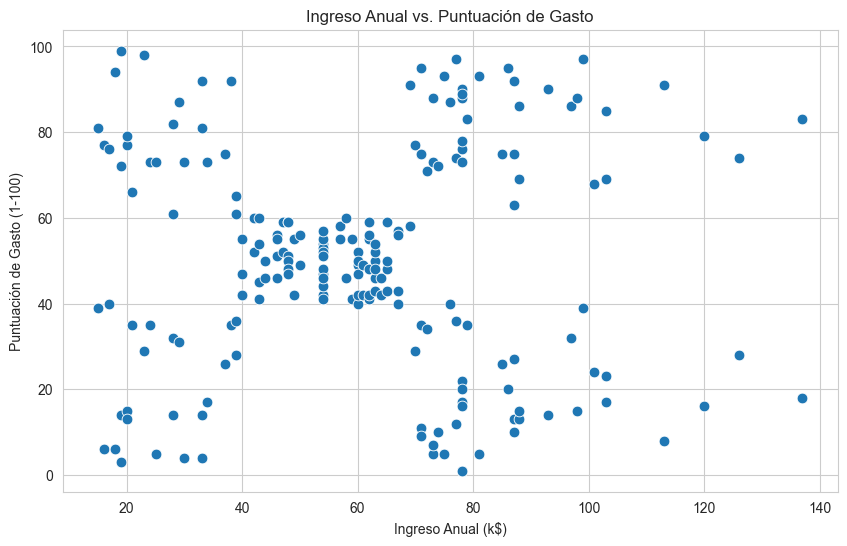

In [2]:
if 'df' in locals():
    # Nos enfocaremos en Ingreso Anual y Puntuación de Gasto
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x='Annual_Income', y='Spending_Score', data=df, s=60)
    plt.title('Ingreso Anual vs. Puntuación de Gasto')
    plt.xlabel('Ingreso Anual (k$)')
    plt.ylabel('Puntuación de Gasto (1-100)')
    plt.show()

**Observaciones del EDA:**
- A simple vista, podemos intuir la existencia de unos **5 grupos o clusters** en los datos:
    1.  Ingresos bajos, gastos bajos.
    2.  Ingresos bajos, gastos altos.
    3.  Ingresos medios, gastos medios.
    4.  Ingresos altos, gastos bajos.
    5.  Ingresos altos, gastos altos.
- Esta estructura visual hace que K-Means sea un candidato ideal para formalizar esta segmentación.

---

## ⚙️ 3. Preprocesamiento de Datos <a id='3-prepro'></a>

Seleccionamos las características y las escalamos, un paso crucial para algoritmos basados en distancia como K-Means.

In [3]:
from sklearn.preprocessing import StandardScaler

if 'df' in locals():
    # Seleccionar las características para el clustering
    X = df[['Annual_Income', 'Spending_Score']]

    # Escalar las características
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    print("Datos seleccionados y escalados.")
    print("Primeras 5 filas de datos escalados:")
    print(X_scaled[:5])

Datos seleccionados y escalados.
Primeras 5 filas de datos escalados:
[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]


---

## 🤖 4. Modelado con K-Means <a id='4-modelado'></a>

Ahora aplicaremos K-Means. El primer paso es determinar el número óptimo de clusters (K).

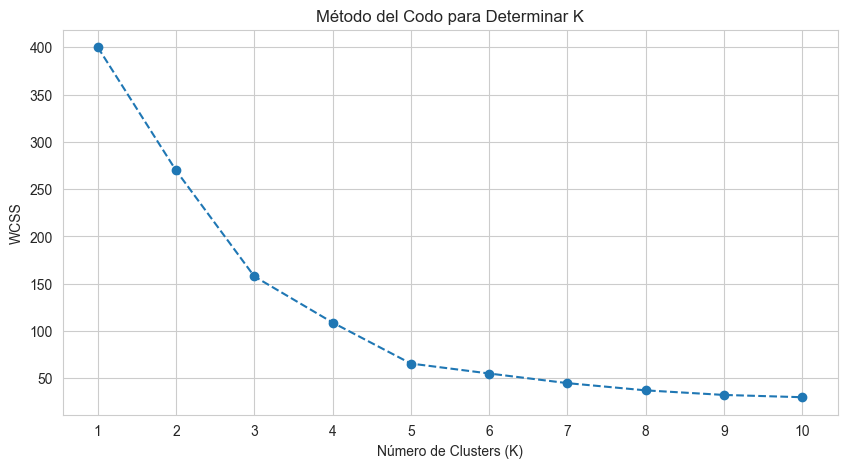

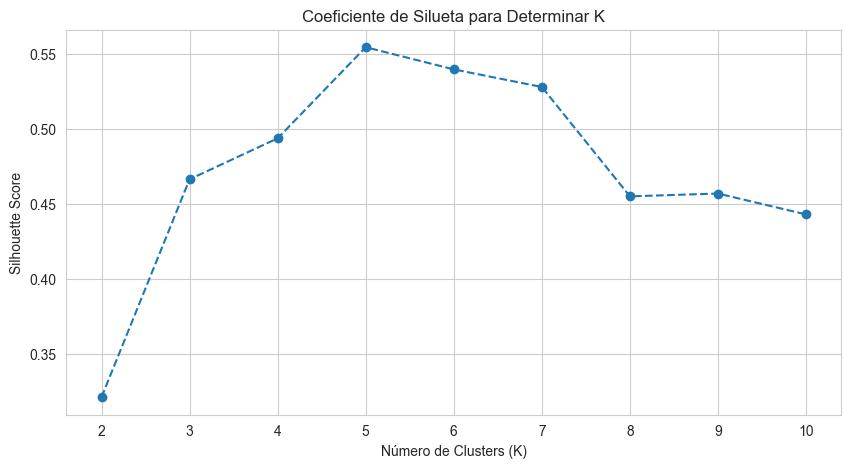

In [4]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

if 'df' in locals():
    # --- 4.1.1 Método del Codo (Elbow Method) ---
    wcss = [] # Within-Cluster Sum of Squares
    k_range = range(1, 11)
    for k in k_range:
        kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
        kmeans.fit(X_scaled)
        wcss.append(kmeans.inertia_)

    plt.figure(figsize=(10, 5))
    plt.plot(k_range, wcss, marker='o', linestyle='--')
    plt.title('Método del Codo para Determinar K')
    plt.xlabel('Número de Clusters (K)')
    plt.ylabel('WCSS')
    plt.xticks(k_range)
    plt.show()
    
    # --- 4.1.2 Coeficiente de Silueta --- 
    silhouette_scores = []
    k_range_sil = range(2, 11) # Silhouette score no está definido para k=1
    for k in k_range_sil:
        kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
        labels = kmeans.fit_predict(X_scaled)
        score = silhouette_score(X_scaled, labels)
        silhouette_scores.append(score)
        
    plt.figure(figsize=(10, 5))
    plt.plot(k_range_sil, silhouette_scores, marker='o', linestyle='--')
    plt.title('Coeficiente de Silueta para Determinar K')
    plt.xlabel('Número de Clusters (K)')
    plt.ylabel('Silhouette Score')
    plt.xticks(k_range_sil)
    plt.show()

**Análisis para K:**
- El **Método del Codo** muestra un "codo" pronunciado en **K=5**. Después de este punto, la reducción en WCSS (inercia) disminuye, sugiriendo que añadir más clusters no aporta una mejora significativa.
- El **Coeficiente de Silueta** alcanza su valor máximo también en **K=5**, lo que refuerza la elección.

Concluimos que el número óptimo de clusters es 5, tal como intuimos en el EDA.

In [5]:
if 'df' in locals():
    # --- 4.2 Entrenamiento del Modelo Final ---
    optimal_k = 5
    kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
    cluster_labels = kmeans_final.fit_predict(X_scaled)

    # Añadir las etiquetas de cluster al DataFrame original
    df['Cluster'] = cluster_labels

    print(f"Modelo K-Means entrenado con K={optimal_k}.")
    print("Primeras filas con la asignación de cluster:")
    display(df.head())

Modelo K-Means entrenado con K=5.
Primeras filas con la asignación de cluster:


,CustomerID,Gender,Age,Annual_Income,Spending_Score,Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


---

## 🖼️ 5. Análisis y Visualización de los Clusters <a id='5-analisis'></a>

Visualicemos los segmentos encontrados y analicemos sus características.

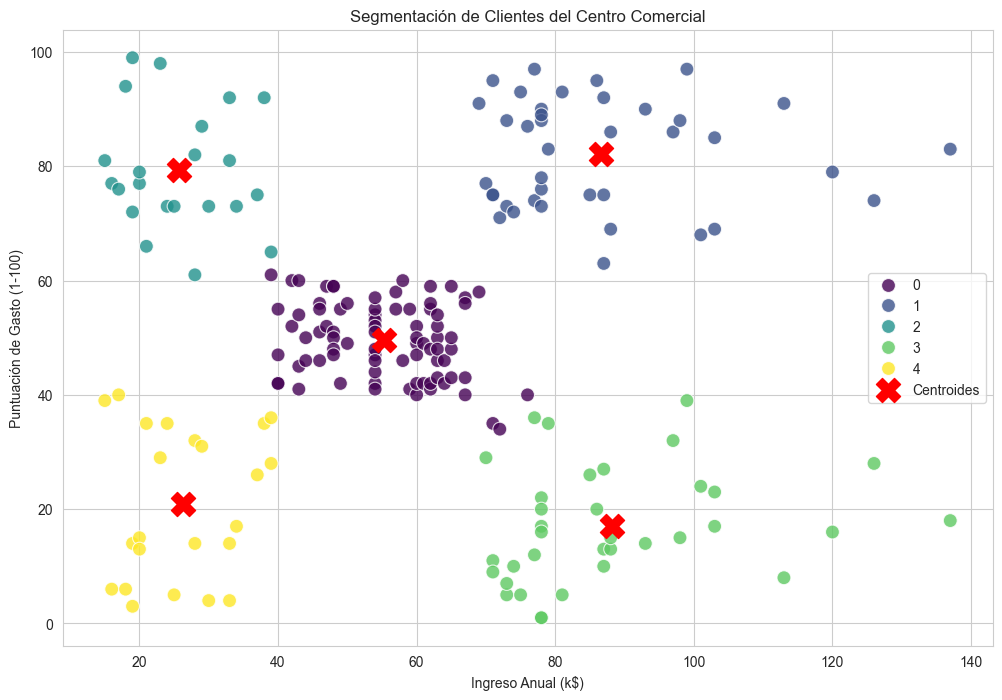

In [6]:
if 'df' in locals():
    plt.figure(figsize=(12, 8))
    sns.scatterplot(x='Annual_Income', y='Spending_Score', hue='Cluster', data=df, palette='viridis', s=100, alpha=0.8, legend='full')
    
    # Dibujar los centroides
    centroids_scaled = kmeans_final.cluster_centers_
    centroids = scaler.inverse_transform(centroids_scaled) # Des-escalar para la visualización
    plt.scatter(centroids[:, 0], centroids[:, 1], s=300, c='red', marker='X', label='Centroides')
    
    plt.title('Segmentación de Clientes del Centro Comercial')
    plt.xlabel('Ingreso Anual (k$)')
    plt.ylabel('Puntuación de Gasto (1-100)')
    plt.legend()
    plt.show()

In [7]:
if 'df' in locals():
    # Analizar las características de cada cluster
    cluster_analysis = df.groupby('Cluster')[['Annual_Income', 'Spending_Score', 'Age']].mean().round(2)
    print("Análisis de las características medias por cluster:")
    display(cluster_analysis)

Análisis de las características medias por cluster:


,Annual_Income,Spending_Score,Age
Cluster,,,
0,55.30,49.52,42.72
1,86.54,82.13,32.69
2,25.73,79.36,25.27
3,88.20,17.11,41.11
4,26.30,20.91,45.22


---

## 🏁 6. Conclusiones y Recomendaciones de Negocio <a id='6-conclusiones'></a>

Hemos identificado 5 segmentos de clientes distintos. Ahora podemos darles un nombre y proponer acciones de marketing.

### Interpretación de los Clusters:

1.  **Cluster 0: Clientes Prudentes**
    - **Características**: Ingresos altos, pero puntuación de gasto baja.
    - **Recomendación**: Son difíciles de convencer. Marketing enfocado en productos de lujo, calidad, durabilidad y exclusividad. Programas de fidelización premium.

2.  **Cluster 1: Clientes Objetivo (Target)**
    - **Características**: Ingresos altos y puntuación de gasto alta.
    - **Recomendación**: ¡El segmento más valioso! Ofrecerles acceso anticipado a nuevos productos, servicios VIP, y campañas de marketing directo sobre artículos de alta gama. Son los embajadores de la marca.

3.  **Cluster 2: Clientes Promedio**
    - **Características**: Ingresos y gastos medios.
    - **Recomendación**: El grupo más grande y estándar. Sensibles a ofertas, promociones (2x1, descuentos) y campañas de marketing masivas. El objetivo es moverlos hacia un mayor gasto.

4.  **Cluster 3: Clientes Ahorradores**
    - **Características**: Ingresos bajos y puntuación de gasto baja.
    - **Recomendación**: Son muy sensibles al precio. Marketing basado en descuentos agresivos, cupones y productos de bajo coste. El objetivo es aumentar la frecuencia de sus visitas.

5.  **Cluster 4: Clientes Impulsivos/Jóvenes**
    - **Características**: Ingresos bajos, pero puntuación de gasto alta.
    - **Recomendación**: Probablemente jóvenes que gastan gran parte de sus ingresos en el centro comercial. Marketing enfocado en tendencias, redes sociales, moda rápida y entretenimiento. Son muy receptivos a las novedades.

### Impacto de Negocio

Esta segmentación permite al centro comercial pasar de un marketing genérico a uno **personalizado y altamente efectivo**, optimizando el retorno de la inversión en cada campaña y mejorando la satisfacción y lealtad de cada tipo de cliente.